In [837]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
from einops import rearrange
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [838]:
import matplotlib.pylab as pylab
import warnings
import matplotlib.cbook

from plot_params import params

warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)

pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [839]:
from reproject import reproject_from_healpix, reproject_to_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

In [840]:
from utils.cart import make_wcs, to_cart

In [841]:
cmap = 'RdBu_r'

In [929]:
extent = 30
n_pixels = 96
pixelsize = 2 * extent / n_pixels
upsample_factor = 4
nside = 128

In [990]:
# Load standard templates
temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dif_cart = to_cart(np.load("../data/fermi_data/template_dif.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_psc_cart = to_cart(np.load("../data/fermi_data/template_psc.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_iso_cart = to_cart(np.load("../data/fermi_data/template_iso.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dsk_cart = to_cart(np.load("../data/fermi_data/template_dsk.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_bub_cart = to_cart(np.load("../data/fermi_data/template_bub.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
mask_ps = np.load("../data/fermi_data/fermidata_pscmask.npy") == 1

# Load Model O templates
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"))
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"))

mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=1.5, mask_ring=True, inner=0, outer=60., custom_mask=mask_ps)) > 0

In [991]:
mesh_dim = np.linspace(0, n_pixels, (n_pixels + 1) * upsample_factor)
interp = RectBivariateSpline(np.arange(n_pixels), np.arange(n_pixels), temp_gce_cart)
temp_gce_cart_upsampled = interp(mesh_dim, mesh_dim)

In [992]:
from models.scd import dnds

In [993]:
n_sim = 10

prior_ps = [[0.001, 10.0, 1.1, -10.0, 5.0, 1., 0.001, 10.0, 1.1, -10.0, 5.0, 1.], 
            [2., 20.0, 1.99, 1.99, 40.0, 4.99, 2., 20.0, 1.99, 1.99, 40.0, 4.99]]

prior_poiss = [[0.001, 0.001, 0.001, 0.001, 6.0, 1.0], 
               [1.5, 1.5, 1.5, 1.5, 12.0, 6.0]]

temps_ps = [temp_gce_cart, temp_dsk_cart]
temps_poiss = [temp_gce_cart, temp_iso_cart, temp_bub_cart, temp_psc_cart, temp_mO_pibrem_cart, temp_mO_ics_cart]

temps_ps_upsampled = []

for temp_ps in temps_ps:
    interp = RectBivariateSpline(np.arange(n_pixels), np.arange(n_pixels), temp_ps)
    temp_ps_upsampled = interp(mesh_dim, mesh_dim)
    temps_ps_upsampled.append(temp_ps_upsampled)

thetas = np.random.uniform(low=prior_poiss[0] + prior_ps[0], high=prior_poiss[1] + prior_ps[1], size=(n_sim, len(prior_ps[0]) + len(prior_poiss[0])))

In [994]:
from tqdm.notebook import tqdm

In [1009]:
s_ary = np.logspace(-1, 2, 10000)
signal_ensemble = np.zeros((n_sim, n_pixels, n_pixels))
dnds_ary = []

for idx_theta, theta in enumerate(tqdm(thetas)):

    idx_theta_ps = len(temps_poiss)
    
    for idx, temp_ps in enumerate(temps_ps):

        theta = thetas[0]
        dnds_ary_temp = dnds(s_ary, theta[idx_theta_ps:idx_theta_ps + 6])
        s_exp = np.trapz(s_ary * dnds_ary_temp, s_ary)
        dnds_ary_temp *= theta[idx_theta_ps] * np.prod(temp_ps.shape) / s_exp
        dnds_ary.append(dnds_ary_temp)
        idx_theta_ps += 6

        n_ps = np.random.poisson(np.trapz(dnds_ary_temp, s_ary))

        logs_ary = np.log10(s_ary)
        dlogs_ary = np.diff(logs_ary)[0] # Spacing in log-space

        s_for_ds_ary = np.logspace(logs_ary[0] - dlogs_ary / 2.0, logs_ary[-1] + dlogs_ary / 2.0, len(s_ary) + 1)
        ds_ary = np.diff(s_for_ds_ary)

        # Sample, accounting for dS factor for log-space sampling
        sample = PDFSampler(s_ary, ds_ary * dnds_ary_temp)(n_ps)

        dist = temps_ps_upsampled[idx]
        dist /= dist.sum() 
        pairs = np.indices(dimensions=temps_ps_upsampled[idx].shape).T # here are all of the x,y pairs 
        inds = np.random.choice(np.arange(np.prod(temps_ps_upsampled[idx].shape)),p=dist.reshape(-1),size=n_ps,replace=True)
        selections = pairs.reshape(-1, 2)[inds]
        hist = np.histogram2d(x=selections[:, 1], y=selections[:, 0], bins=n_pixels * upsample_factor, weights=sample)[0]

        sigma_psf = 0.2
        signal = np.random.poisson(gaussian_filter(hist, sigma=sigma_psf / (pixelsize / upsample_factor), truncate=8.))

        b = signal.shape[0] // upsample_factor

        signal_ensemble[idx_theta, :, :] += signal.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

    signal_ensemble[idx_theta, :, :] += np.random.poisson(np.einsum('i,ijk->jk', theta[:len(temps_poiss)], np.array(temps_poiss)))

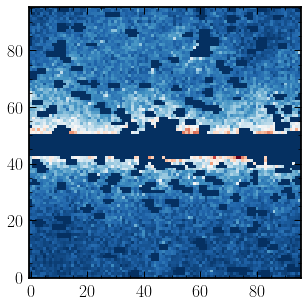

In [1010]:
plt.imshow(signal_ensemble[0] * ~mask_roi, vmin=0, vmax=100, origin='lower', cmap=cmap)